(16)=
# Chapter 16: Root Finding & Newton's Method

**Topics Covered:**
- What is a root and why do we need to find it numerically?
- Polynomial roots with `np.roots`
- Bisection method: slow but guaranteed
- Newton's method: fast but requires a derivative
- `scipy.optimize.brentq`: robust black-box root finder
- `scipy.optimize.fsolve`: systems of nonlinear equations
- ChE application: van der Waals equation, reaction equilibrium

## Motivation: Equations You Cannot Solve by Hand Easily

Chemical engineering is full of equations where the unknown appears in a complicated way — inside an exponential, a logarithm, or a cubic. For example:

**Van der Waals equation of state** (find molar volume $V$ at given $T$, $P$):
$$\left(P + \frac{a}{V^2}\right)(V - b) = RT$$

Rearranging gives a **cubic** in $V$ — three possible roots, and no simple formula for the one you want.

**Antoine equation** (find boiling point $T_b$ at a given pressure $P$):
$$\log_{10} P = A - \frac{B}{C + T_b}$$

Solvable analytically here, but the same structure embedded in a larger model is not.

**Reaction equilibrium** (find equilibrium conversion $X_e$):
$$K_{eq}(T) = \frac{X_e^2}{(1 - X_e)^2}$$

For more complex stoichiometry the algebraic expression becomes intractable.

The strategy in all cases: **rewrite as $f(x) = 0$ and find the root numerically.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve

(16.1)=
## 16.1 What Is a Root?

A **root** (or **zero**) of a function $f(x)$ is any value $x^*$ where:
$$f(x^*) = 0$$

Almost any equation can be rewritten in this form. For example:

| Original equation | Rewrite as $f(x) = 0$ |
|-------------------|----------------------|
| $x^2 = 4$ | $f(x) = x^2 - 4$ |
| $e^x = 2x + 1$ | $f(x) = e^x - 2x - 1$ |
| $(P + a/V^2)(V-b) = RT$ | $f(V) = (P + a/V^2)(V-b) - RT$ |

Geometrically, a root is where the curve $y = f(x)$ **crosses zero** — where it intersects the x-axis.

The key idea: **always plot your function first** to see how many roots there are and roughly where they are.

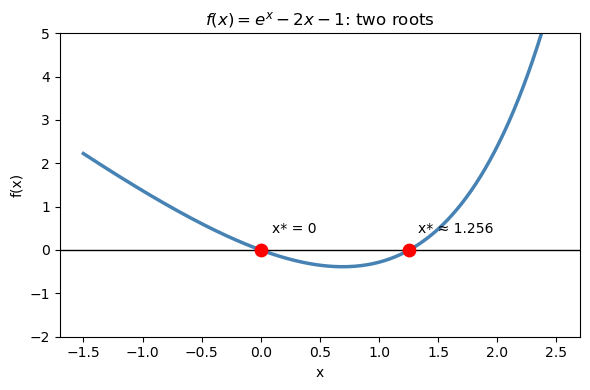

In [2]:
# Example: f(x) = e^x - 2x - 1  has two roots
def f_demo(x):
    return np.exp(x) - 2*x - 1

x = np.linspace(-1.5, 2.5, 300)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, f_demo(x), 'steelblue', linewidth=2.5)
ax.axhline(0, color='k', linewidth=1)
# ax.scatter([0, np.log(2) + 0*1],  # roots: x=0 and x≈1.256
#            [0, 0], color='red', s=80, zorder=5, label='Roots')

# find second root precisely
root2 = brentq(f_demo, 1, 2)
ax.scatter([0, root2], [0, 0], color='red', s=80, zorder=5)
ax.annotate(f'x* = 0', (0, 0), textcoords='offset points', xytext=(8, 12), fontsize=10)
ax.annotate(f'x* ≈ {root2:.3f}', (root2, 0), textcoords='offset points', xytext=(6, 12), fontsize=10)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(r'$f(x) = e^x - 2x - 1$: two roots')
ax.set_ylim(-2, 5)
plt.tight_layout()
plt.show()

(16.2)=
## 16.2 Special Case: Polynomial Roots with `np.roots`

If your equation happens to be a **polynomial**, NumPy can find **all** roots at once — including complex ones — using `np.roots`. This is much faster than running a bracketed solver multiple times.

### How it works

`np.roots` finds roots by computing the **eigenvalues of the companion matrix** of the polynomial. For a degree-$n$ polynomial, the companion matrix is an $n \times n$ matrix whose eigenvalues are exactly the roots. This is a linear algebra approach — no iteration, no initial guess needed.

**Syntax:** pass the coefficients from **highest to lowest degree**:

$$p(x) = c_0 x^n + c_1 x^{n-1} + \cdots + c_n \quad \Rightarrow \quad \texttt{np.roots([}c_0,\, c_1,\, \ldots,\, c_n\texttt{])}$$

### Example: van der Waals as a cubic polynomial

Expanding the van der Waals equation $(P + a/V^2)(V - b) = RT$ gives a cubic in $V$:

$$PV^3 - (Pb + RT)V^2 + aV - ab = 0$$

We can find all three roots directly with `np.roots` and pick the physically meaningful one.

In [12]:
R_gas = 0.08314   # L·bar / (mol·K)
a_co2 = 3.658     # L²·bar / mol²
b_co2 = 0.04286   # L/mol
T_co2 = 310.0     # K
P_co2 = 70.0      # bar

# Cubic coefficients: P*V^3 - (P*b + R*T)*V^2 + a*V - a*b = 0
coeffs = [P_co2,
          -(P_co2*b_co2 + R_gas*T_co2),
          a_co2,
          -a_co2*b_co2
]


all_roots = np.roots(coeffs)
# print(all_roots)
# print(np.isreal(all_roots[0]))
# print(all_roots[0].real)

print("All roots of the van der Waals cubic:")
for i, r in enumerate(all_roots):
    if np.isreal(r):
        print(f"  Root {i+1}: V = {r.real:.5f} L/mol  (real)")
    else:
        print(f"  Root {i+1}: V = {r}  (complex — not physical)")

# The physical root is the real positive root greater than b

All roots of the van der Waals cubic:
  Root 1: V = 0.21940 L/mol  (real)
  Root 2: V = (0.09582797990203343+0.032026426303389866j)  (complex — not physical)
  Root 3: V = (0.09582797990203343-0.032026426303389866j)  (complex — not physical)


### Under the hood: why eigenvalues = roots?

**Start with a degree-2 polynomial** $p(x) = x^2 + a_1 x + a_2$.

Its companion matrix is the $2 \times 2$ matrix:

$$C = \begin{bmatrix} -a_1 & -a_2 \\ 1 & 0 \end{bmatrix}$$

Now compute the characteristic polynomial of $C$ — i.e., set $\det(C - \lambda I) = 0$:

$$\det\begin{bmatrix} -a_1 - \lambda & -a_2 \\ 1 & -\lambda \end{bmatrix} = (-a_1 - \lambda)(-\lambda) - (-a_2)(1)$$

$$= \lambda^2 + a_1 \lambda + a_2$$

That is **exactly** $p(\lambda)$. So $\det(C - \lambda I) = 0$ is the same equation as $p(\lambda) = 0$ — the eigenvalues of $C$ are the roots of $p$.

The same construction works for any degree $n$: the companion matrix is always built so that its characteristic polynomial equals the original polynomial.

**General form** for a monic degree-$n$ polynomial $x^n + a_1 x^{n-1} + \cdots + a_n$:

$$C = \begin{bmatrix} -a_1 & -a_2 & \cdots & -a_n \\\\ 1 & 0 & \cdots & 0 \\\\ 0 & 1 & \cdots & 0 \\\\ \vdots & & \ddots & \vdots \\\\ 0 & 0 & \cdots & 0 \end{bmatrix}$$

The code below demonstrates this with a quadratic first, then the cubic.

In [15]:
# --- 2x2 demo: p(x) = x^2 - 5x + 6  (roots are 2 and 3) --- (x1 = 2, x2 =3)
# a1 = -5, a2 = 6
C2 = np.array([[ 5., -6.],
               [ 1.,  0.]])

print("2x2 companion matrix C:")
print(C2)
print(f"det(C - lI) = l^2 - 5l + 6  =>  eigenvalues: {np.linalg.eigvals(C2).real}")
print(f"np.roots result:                              {np.roots([1,-5,6])}")

print()

2x2 companion matrix C:
[[ 5. -6.]
 [ 1.  0.]]
det(C - lI) = l^2 - 5l + 6  =>  eigenvalues: [3. 2.]
np.roots result:                              [3. 2.]



(16.3)=
## 16.3 Bisection Method

### Mathematical background

The bisection method is grounded in the **Intermediate Value Theorem (IVT)** from calculus:

> If $f$ is continuous on $[a, b]$ and $f(a)$ and $f(b)$ have opposite signs, then there exists at least one root $x^* \in (a, b)$.

The sign change $f(a) \cdot f(b) < 0$ is not just a programming check — it is the mathematical guarantee that a root exists in the interval.

**Error analysis:**

After $n$ iterations, the interval has width $(b-a)/2^n$, so the root is known to within:
$$|x_n - x^*| \leq \frac{b - a}{2^n}$$

To achieve a tolerance $\epsilon$, you need at least $n \geq \log_2\!\left(\dfrac{b-a}{\epsilon}\right)$ iterations.

For example, starting from an interval of width 1 and wanting $\epsilon = 10^{-8}$: you need $\log_2(10^8) \approx 27$ iterations. That is slow but **completely predictable** — this is why bisection is called *linearly convergent*.

**Algorithm:**
1. Start with $[a, b]$ where $f(a) \cdot f(b) < 0$
2. Compute midpoint $m = (a + b)/2$
3. If $f(a) \cdot f(m) < 0$: root is in $[a, m]$ → set $b = m$; else set $a = m$
4. Repeat until $(b - a)/2 < \epsilon$

**Strengths:** Always works if the bracket is valid. No derivative needed. Error bound is known in advance.

**Weaknesses:** Slow ($\sim 27$ iterations for 8 decimal places). Needs a bracket.

### Visual: bisection step by step

Each panel below shows one iteration of the algorithm:
- The **current bracket** $[a, b]$ is shaded in red (the region we know contains the root)
- The **midpoint** $m = (a+b)/2$ is shown as a dashed vertical line
- Based on the sign of $f(a) \cdot f(m)$, we **keep one half** and discard the other

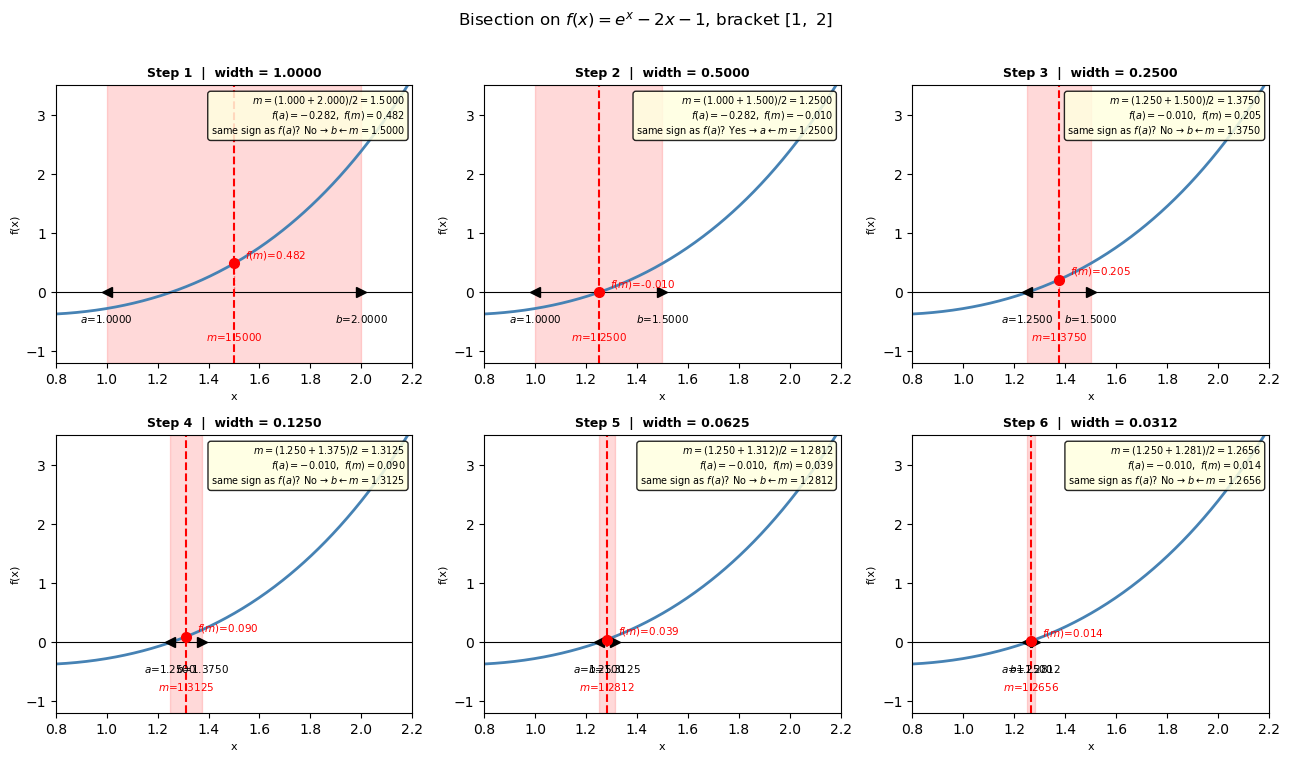

In [16]:
def f_demo(x):
    return np.exp(x) - 2*x - 1

a0, b0 = 1.0, 2.0   # initial bracket
n_panels = 6

# Run bisection and record state BEFORE each step
states = []   # (a, b, m)
a, b = a0, b0
for _ in range(n_panels):
    m = (a + b) / 2
    states.append((a, b, m))
    if f_demo(a) * f_demo(m) < 0:
        b = m
    else:
        a = m

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
axes = axes.flatten()
x_plot = np.linspace(0.8, 2.2, 400)

for k, (ak, bk, mk) in enumerate(states):
    ax = axes[k]

    # function curve
    ax.plot(x_plot, f_demo(x_plot), "steelblue", lw=2)
    ax.axhline(0, color="k", lw=0.8)

    # shade current bracket
    ax.axvspan(ak, bk, alpha=0.15, color="red")

    # midpoint vertical line + dot
    ax.axvline(mk, color="red", ls="--", lw=1.5)
    ax.plot(mk, f_demo(mk), "ro", ms=7, zorder=5)

    # label a and b on x-axis with their values
    ax.plot(ak, 0, "k<", ms=7, clip_on=False)
    ax.plot(bk, 0, "k>", ms=7, clip_on=False)
    ax.annotate(f"$a$={ak:.4f}", (ak, 0), xytext=(0, -22),
                textcoords="offset points", ha="center", fontsize=7.5, color="black")
    ax.annotate(f"$b$={bk:.4f}", (bk, 0), xytext=(0, -22),
                textcoords="offset points", ha="center", fontsize=7.5, color="black")

    # label m with its value on the x-axis
    ax.annotate(f"$m$={mk:.4f}", (mk, 0), xytext=(0, -35),
                textcoords="offset points", ha="center", fontsize=7.5, color="red")

    # drop a vertical line from f(m) down to x-axis to show f(m) value
    ax.vlines(mk, 0, f_demo(mk), color="red", lw=1, ls=":", alpha=0.6)
    ax.annotate(f"$f(m)$={f_demo(mk):.3f}", (mk, f_demo(mk)),
                xytext=(8, 4), textcoords="offset points", fontsize=7.5, color="red")

    # decision logic annotation
    if f_demo(ak) * f_demo(mk) < 0:
        decision = (f"$m = ({ak:.3f}+{bk:.3f})/2 = {mk:.4f}$\n"
                    f"$f(a)={f_demo(ak):.3f},\ f(m)={f_demo(mk):.3f}$\n"
                    f"same sign as $f(a)$? No → $b \\leftarrow m={mk:.4f}$")
    else:
        decision = (f"$m = ({ak:.3f}+{bk:.3f})/2 = {mk:.4f}$\n"
                    f"$f(a)={f_demo(ak):.3f},\ f(m)={f_demo(mk):.3f}$\n"
                    f"same sign as $f(a)$? Yes → $a \\leftarrow m={mk:.4f}$")

    ax.set_title(f"Step {k+1}  |  width = {bk-ak:.4f}", fontsize=9, fontweight="bold")
    ax.text(0.98, 0.97, decision, transform=ax.transAxes,
            fontsize=7, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.85))

    ax.set_xlim(0.8, 2.2)
    ax.set_ylim(-1.2, 3.5)
    ax.set_xlabel("x", fontsize=8)
    ax.set_ylabel("f(x)", fontsize=8)

plt.suptitle(r"Bisection on $f(x)=e^x-2x-1$, bracket $[1,\ 2]$", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


<function __main__.f_demo(x)>

Root found: x* = 1.2564312071
f(x*)      = -2.37e-09
Iterations : 26


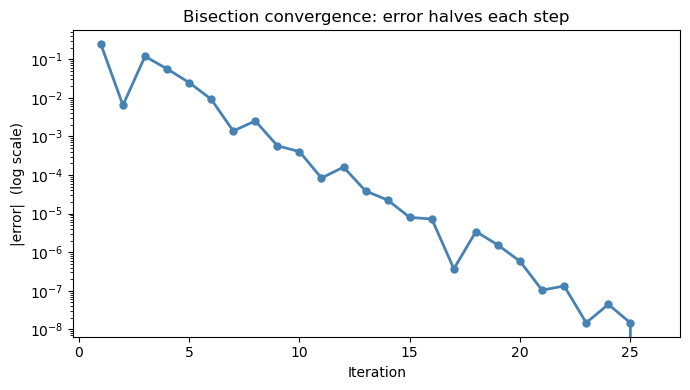

In [18]:
# from scipy.optimize import bisect

def bisection(f, a, b, tol=1e-8, max_iter=100):
    """Find root of f in [a, b] by bisection."""
    assert f(a) * f(b) < 0, "f(a) and f(b) must have opposite signs"

    history = []   # track midpoints for visualization
    for i in range(max_iter):
        m = (a + b) / 2.0
        history.append(m)
        if abs(f(m)) < tol or (b - a) / 2 < tol:
            break
        if f(a) * f(m) < 0:
            b = m
        else:
            a = m
    return m, history

# Find the root of f(x) = e^x - 2x - 1  near x = 1.2
def f_demo(x):
    return np.exp(x) - 2*x - 1


root_bis, history = bisection(f_demo, a=1.0, b=2.0)

print(f"Root found: x* = {root_bis:.10f}")
print(f"f(x*)      = {f_demo(root_bis):.2e}")
print(f"Iterations : {len(history)}")

# Plot convergence
errors = [abs(m - root_bis) for m in history]
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(errors)+1), errors, 'o-', color='steelblue', linewidth=2, markersize=5)
ax.set_xlabel('Iteration'); ax.set_ylabel('|error|  (log scale)')
ax.set_title('Bisection convergence: error halves each step')
plt.tight_layout()
plt.show()

### (Optional) Using `scipy.optimize.bisect`

SciPy provides a built-in bisection solver so you do not need to implement it yourself:

```python
from scipy.optimize import bisect

root = bisect(f, a, b)              # basic usage
root = bisect(f, a, b, xtol=1e-12)  # tighter tolerance
root = bisect(f, a, b, args=(p1,))  # pass extra parameters to f
```

**Requirements:** same as hand-coded bisection — $f(a)$ and $f(b)$ must have opposite signs.

The result is identical to our hand-coded version, but `bisect` is optimized internally and handles edge cases for you.

In [21]:
from scipy.optimize import bisect
# scipy.optimize.bisect — same problem, one line
root_scipy = bisect(f_demo, 1.0, 2.0) # built in
root_hand,  _ = bisection(f_demo, 1.0, 2.0) # custom function

print(f"scipy bisect:      x* = {root_scipy:.10f}")
print(f"hand-coded:        x* = {root_hand:.10f}")
print(f"difference:             {abs(root_scipy - root_hand):.2e}")


scipy bisect:      x* = 1.2564312086
hand-coded:        x* = 1.2564312071
difference:             1.57e-09


(16.4)=
## 16.4 Newton's Method

### Mathematical background

Newton's method comes from a **first-order Taylor expansion** of $f$ around the current guess $x_n$:

$$f(x) \approx f(x_n) + f'(x_n)(x - x_n)$$

We want $f(x^*) = 0$, so we set the right-hand side to zero and solve for $x$:

$$0 = f(x_n) + f'(x_n)(x_{n+1} - x_n)$$
$$\boxed{x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}}$$

Geometrically: draw the tangent line to $f$ at $(x_n,\, f(x_n))$. The next guess $x_{n+1}$ is where that tangent line crosses the x-axis.

### Convergence: quadratic vs. linear

The error $e_n = x_n - x^*$ satisfies:

$$|e_{n+1}| \approx \frac{|f''(x^*)|}{2|f'(x^*)|} \, |e_n|^2$$

The error is **squared** at each step — this is called **quadratic convergence**. Concretely:

| Iteration | Approximate error |
|-----------|------------------|
| 0 | $10^{-1}$ |
| 1 | $10^{-2}$ |
| 2 | $10^{-4}$ |
| 3 | $10^{-8}$ |
| 4 | $10^{-16}$ (machine precision) |

Compare to bisection: to reach $10^{-16}$ from an interval of width 1 takes $\log_2(10^{16}) \approx 53$ iterations, versus ~5 for Newton.

### When Newton's method can fail

- **$f'(x_n) \approx 0$**: the tangent line is nearly horizontal and the next guess shoots far away
- **Poor initial guess**: if $x_0$ is far from the root, the tangent may point toward a completely different region
- **Multiple roots close together**: the method may oscillate between roots

**Rule of thumb:** Plot $f(x)$ first, pick $x_0$ close to the root you want, and verify $f'(x_0) \neq 0$.

### Newton's method step by step

At each step we:
1. Evaluate $f(x_n)$ and $f'(x_n)$ at the current guess
2. Draw the **tangent line** at $(x_n,\ f(x_n))$: $\quad y = f(x_n) + f'(x_n)(x - x_n)$
3. Find where that tangent crosses zero → this is $x_{n+1}$:
$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$
4. **Stop** when either:
   - $|f(x_n)| < \epsilon$ (residual is small enough), or
   - $|x_{n+1} - x_n| < \epsilon$ (step size is negligible)

Each panel below shows one iteration with the numbers filled in.

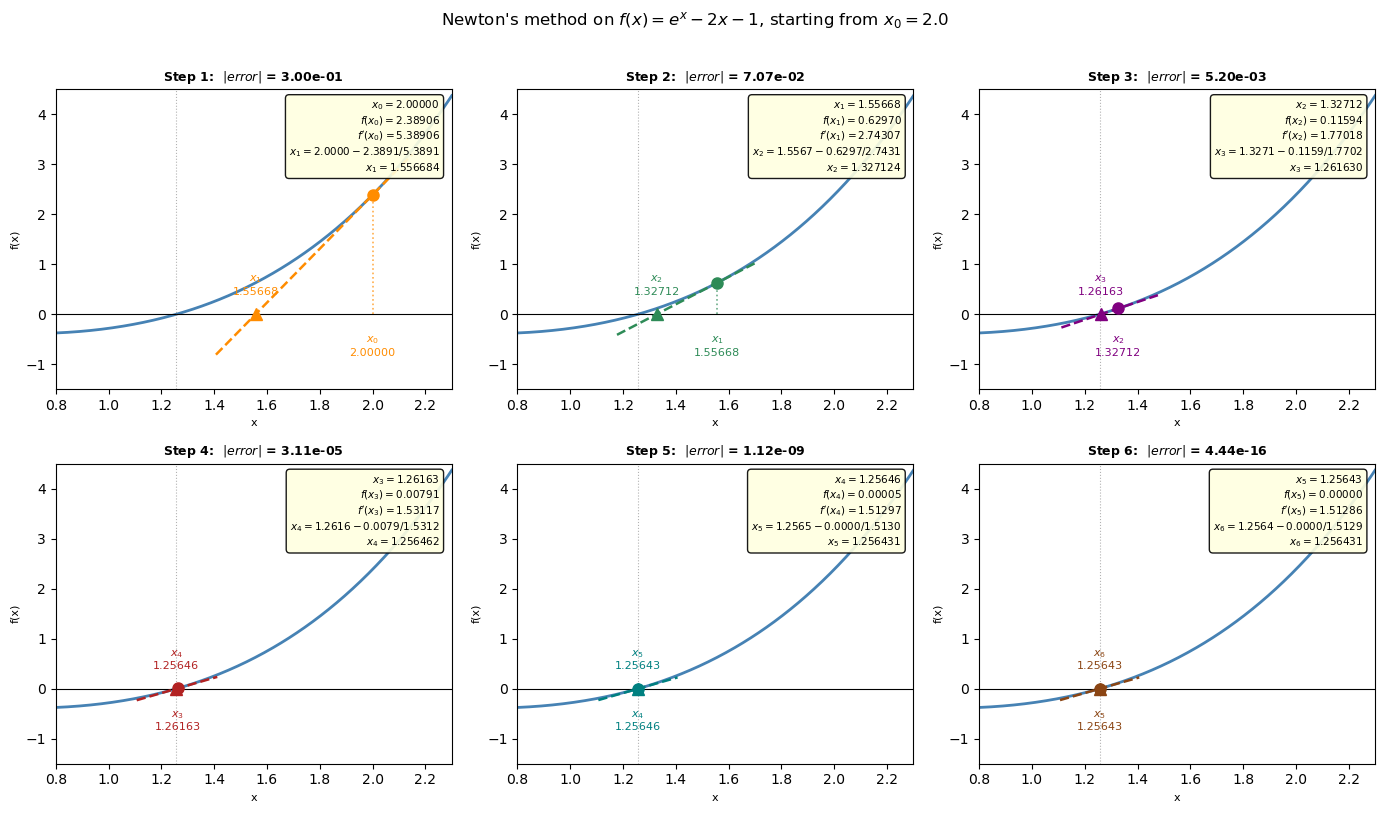

In [22]:
def f(x):  return np.exp(x) - 2*x - 1
def df(x): return np.exp(x) - 2

x0 = 2.0
n_panels = 6
colors = ["darkorange", "seagreen", "purple", "firebrick", "teal", "saddlebrown"]

# Collect iterates
iterates = [x0]
for _ in range(n_panels):
    xn = iterates[-1]
    iterates.append(xn - f(xn) / df(xn))

true_root = brentq(f, 1.0, 2.0)
x_plot = np.linspace(0.8, 2.3, 400)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for k in range(n_panels):
    ax = axes[k]
    xn  = iterates[k]
    xn1 = iterates[k + 1]
    fn  = f(xn)
    dfn = df(xn)
    color = colors[k]

    # --- curve ---
    ax.plot(x_plot, f(x_plot), "steelblue", lw=2, zorder=2)
    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(true_root, color="gray", lw=0.8, ls=":", alpha=0.6)

    # --- tangent line through (xn, fn) ---
    # extends a bit left and right so it clearly crosses zero
    x_left  = min(xn, xn1) - 0.15
    x_right = max(xn, xn1) + 0.15
    x_tan = np.linspace(x_left, x_right, 100)
    y_tan = fn + dfn * (x_tan - xn)
    ax.plot(x_tan, y_tan, "--", color=color, lw=1.8, zorder=3)

    # --- vertical drop from (xn, fn) to x-axis ---
    ax.vlines(xn, 0, fn, color=color, lw=1.2, ls=":", alpha=0.7)

    # --- current point (xn, f(xn)) ---
    ax.plot(xn, fn, "o", color=color, ms=8, zorder=5)

    # --- next guess xn1 on x-axis ---
    ax.plot(xn1, 0, "^", color=color, ms=9, zorder=6)

    # --- x-axis labels ---
    ax.annotate(f"$x_{k}$\n{xn:.5f}", (xn, 0),
                xytext=(0, -30), textcoords="offset points",
                ha="center", fontsize=8, color=color)
    ax.annotate(f"$x_{{{k+1}}}$\n{xn1:.5f}", (xn1, 0),
                xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=8, color=color)

    # --- annotation box: show the arithmetic ---
    box_text = (
        f"$x_{k} = {xn:.5f}$\n"
        f"$f(x_{k}) = {fn:.5f}$\n"
        f"$f'(x_{k}) = {dfn:.5f}$\n"
        f"$x_{{{k+1}}} = {xn:.4f} - {fn:.4f}/{dfn:.4f}$\n"
        f"$x_{{{k+1}}} = {xn1:.6f}$"
    )
    ax.text(0.97, 0.97, box_text, transform=ax.transAxes,
            fontsize=7.5, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.35", fc="lightyellow", alpha=0.9))

    ax.set_title(f"Step {k+1}:  $|error|$ = {abs(xn1 - true_root):.2e}", fontsize=9, fontweight="bold")
    ax.set_xlim(0.8, 2.3)
    ax.set_ylim(-1.5, 4.5)
    ax.set_xlabel("x", fontsize=8)
    ax.set_ylabel("f(x)", fontsize=8)

plt.suptitle(
    r"Newton's method on $f(x)=e^x-2x-1$, starting from $x_0=2.0$",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


$$(x_n, f(x_n))$$
$$y = f(x_n) + f'(x_n)(x - x_n)$$

In [47]:
from scipy.optimize import newton

def f(x):   return np.exp(x) - 2*x - 1
def df(x):  return np.exp(x) - 2        # f'(x) = e^x - 2

# Run 4 Newton steps from x0 = 2.0
x0 = 2.0
iterates = [x0]
for _ in range(4):
    xn = iterates[-1]
    iterates.append(xn - f(xn) / df(xn))

print(f"{'Step':>4}  {'x_n':>14}  {'f(x_n)':>14}  {'|error|':>14}")
print("-" * 52)
true_root = brentq(f, 1, 2)
for i, xi in enumerate(iterates):
    print(f"  {i:>2}  {xi:>14.10f}  {f(xi):>14.2e}  {abs(xi - true_root):>14.2e}")

Step             x_n          f(x_n)         |error|
----------------------------------------------------
   0    2.0000000000        2.39e+00        7.44e-01
   1    1.5566837578        6.30e-01        3.00e-01
   2    1.3271236710        1.16e-01        7.07e-02
   3    1.2616298127        7.91e-03        5.20e-03
   4    1.2564623176        4.71e-05        3.11e-05


### (Optional) Using `scipy.optimize.newton`

SciPy also provides a built-in Newton solver:

```python
from scipy.optimize import newton

root = newton(f, x0)           # secant method (no derivative needed)
root = newton(f, x0, fprime=df)  # full Newton (faster, uses derivative)
root = newton(f, x0, fprime=df, tol=1e-12)  # tighter tolerance
```

- Without `fprime`: SciPy uses the **secant method** — approximates the derivative from two nearby points
- With `fprime`: uses true **Newton's method** with the analytical derivative

Providing `fprime` is faster and more reliable when you can compute $f'(x)$.

In [45]:
# scipy.optimize.newton — same problem, one line
root_secant = newton(f, x0=2.0)              # secant method (no fprime)
root_newton = newton(f, x0=2.0, fprime=df)   # full Newton with derivative

print(f"scipy newton (secant):   x* = {root_secant:.10f}")
print(f"scipy newton (Newton):   x* = {root_newton:.10f}")
print(f"hand-coded Newton:       x* = {true_root:.10f}")
print(f"difference (secant vs Newton): {abs(root_secant - root_newton):.2e}")


scipy newton (secant):   x* = 1.2564312086
scipy newton (Newton):   x* = 1.2564312086
hand-coded Newton:       x* = 1.2564312086
difference (secant vs Newton): 4.44e-16


### 16.3.2 Newton vs. bisection: convergence comparison

Notice how Newton's error shrinks quadratically — the curve drops steeply compared to bisection's straight linear decay on a log plot.

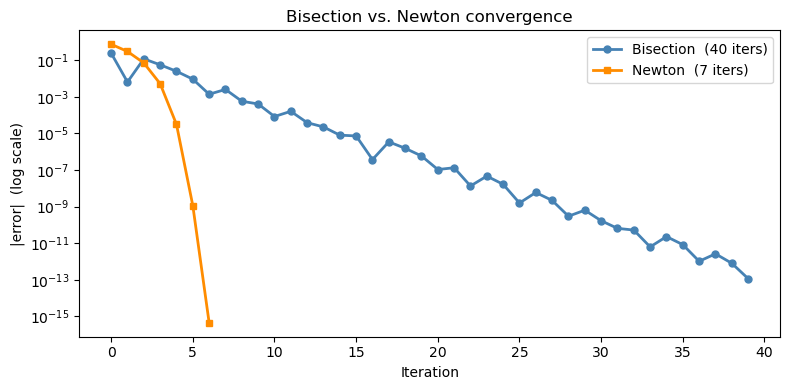

In [48]:
def newton(f, df, x0, tol=1e-12, max_iter=30):
    x = x0
    history = [x]
    for _ in range(max_iter):
        x = x - f(x) / df(x)
        history.append(x)
        if abs(f(x)) < tol:
            break
    return x, history

_, bis_hist  = bisection(f, 1.0, 2.0, tol=1e-12)
_, newt_hist = newton(f, df, x0=2.0)

bis_errors  = [abs(m - true_root) for m in bis_hist]
newt_errors = [abs(m - true_root) for m in newt_hist]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(len(bis_errors)),  bis_errors,  'o-', color='steelblue',
            linewidth=2, markersize=5, label=f'Bisection  ({len(bis_errors)} iters)')
ax.semilogy(range(len(newt_errors)), newt_errors, 's-', color='darkorange',
            linewidth=2, markersize=5, label=f"Newton  ({len(newt_errors)} iters)")
ax.set_xlabel('Iteration'); ax.set_ylabel('|error|  (log scale)')
ax.set_title('Bisection vs. Newton convergence')
ax.legend()
plt.tight_layout()
plt.show()

(16.5)=
## 16.5 `scipy.optimize.brentq`: The Practical Choice

### Mathematical background

Brent's method (1973) is the algorithm inside `brentq`. It is a hybrid that switches intelligently between three techniques:

1. **Bisection** — always makes progress, but slow ($O(1/2^n)$)
2. **Secant method** — approximates the derivative using two recent points instead of computing it analytically:
$$x_{n+1} = x_n - f(x_n)\,\frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$$
   This is like Newton's method but replaces $f'(x_n)$ with a finite-difference slope. Converges *superlinearly* (order ~1.6) but has no bracket guarantee on its own.

3. **Inverse quadratic interpolation** — fits a quadratic through three recent $(f, x)$ pairs and uses its inverse to predict the root. Even faster than the secant method when $f$ is smooth.

At each step, Brent's method tries inverse quadratic interpolation or the secant step first. If either would step outside the current bracket, it falls back to bisection. This gives **near-Newton speed** with **bisection's guarantee** — the best of both worlds.

**Key syntax:**
```python
from scipy.optimize import brentq

root = brentq(f, a, b)               # basic usage
root = brentq(f, a, b, xtol=1e-12)   # tighter tolerance
root = brentq(f, a, b, args=(p1,))   # pass extra parameters to f
```

**Requirements:**
- $f$ must be continuous on $[a, b]$
- $f(a)$ and $f(b)$ must have **opposite signs** — if not, you get a `ValueError`
- **Always plot first** to confirm the sign change and locate the bracket

### 16.4.1 Finding the van der Waals molar volume

The van der Waals equation of state for CO₂ at $T = 310$ K, $P = 70$ bar:

$$\left(P + \frac{a}{V^2}\right)(V - b) = RT \quad \Longrightarrow \quad f(V) = \left(P + \frac{a}{V^2}\right)(V - b) - RT = 0$$

van der Waals constants for CO₂: $a = 3.658$ L²·bar/mol², $b = 0.04286$ L/mol.

**Step 1:** Always plot $f(V)$ first to find a good bracket.

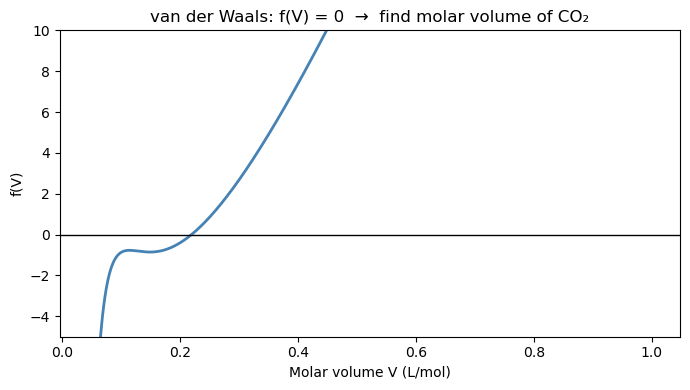

Sign change between V = 0.2182 and 0.2201


In [ ]:
R = 0.08314   # L·bar / (mol·K)
a = 3.658     # L²·bar / mol²   (CO2)
b = 0.04286   # L/mol           (CO2)
T = 310.0     # K
P = 70.0      # bar



# Plot to find brackets (avoid V < b where the equation is undefined)
V_range = np.linspace(b + 0.001, 1.0, 500)



In [ ]:
# Solve with brentq using the bracket found above


# Compare to ideal gas: V_ideal = RT/P
V_ideal = R * T / P

print(f"van der Waals molar volume : V = {V_root:.5f} L/mol")
print(f"Ideal gas molar volume     : V = {V_ideal:.5f} L/mol")
print(f"Compressibility factor Z = PV/RT = {P*V_root/(R*T):.4f}  (1.000 = ideal)")
print(f"Residual f(V_root) = {f_vdw(V_root):.2e}")

(16.6)=
## 16.6 Systems of Nonlinear Equations: `scipy.optimize.fsolve`

### Mathematical background

`brentq` handles one equation, one unknown. For $n$ equations and $n$ unknowns, we need to solve:

$$\mathbf{F}(\mathbf{x}) = \mathbf{0}, \quad \mathbf{F}: \mathbb{R}^n \to \mathbb{R}^n$$

`fsolve` uses **Newton's method in multiple dimensions**. Recall the scalar Newton step:
$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

In $n$ dimensions, the derivative $f'(x)$ becomes the **Jacobian matrix** $J$, where each entry is a partial derivative:
$$J_{ij} = \frac{\partial F_i}{\partial x_j}$$

The multidimensional Newton step becomes:
$$\mathbf{x}_{n+1} = \mathbf{x}_n - J(\mathbf{x}_n)^{-1}\, \mathbf{F}(\mathbf{x}_n)$$

or equivalently, solve the linear system $J(\mathbf{x}_n)\,\Delta\mathbf{x} = -\mathbf{F}(\mathbf{x}_n)$ and set $\mathbf{x}_{n+1} = \mathbf{x}_n + \Delta\mathbf{x}$.

`fsolve` estimates $J$ numerically via finite differences — you don't need to derive it by hand.

### Key differences from `brentq`

| Property | `brentq` | `fsolve` |
|----------|----------|----------|
| Equations | 1 | $N$ |
| Unknowns | 1 | $N$ |
| Needs bracket | Yes | No |
| Needs initial guess | No | **Yes — critical** |
| Guaranteed to converge | Yes (bracket valid) | No |
| Silent wrong answers | No | **Possible — always verify** |

Because `fsolve` has no bracket guarantee, it can converge to a wrong answer without warning. **Always check residuals** after solving.

**Syntax:**
```python
from scipy.optimize import fsolve

def F(vars):
    x, y = vars
    return [eq1, eq2]      # list of residuals, one per equation

solution = fsolve(F, x0=[x_guess, y_guess])
print(F(solution))          # must be near [0, 0]
```

### 16.5.1 Simple example: two nonlinear equations

Find the intersection of $y = x^2$ and $y = 2 - x$:
$$\begin{cases} y - x^2 = 0 \\ y + x - 2 = 0 \end{cases}$$

Solution 1: x = -2.000000,  y = 4.000000   residuals: [0.0, 0.0]
Solution 2: x = 1.000000,  y = 1.000000   residuals: [0.0, 0.0]


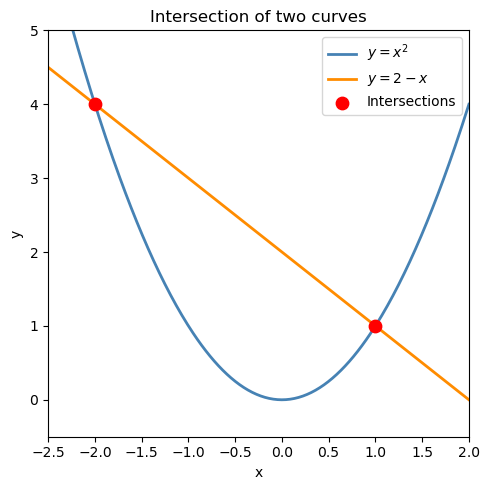

In [ ]:


# Two intersection points — use different initial guesses to find each
sol1 = 
sol2 = 

print(f"Solution 1: x = {sol1[0]:.6f},  y = {sol1[1]:.6f}   residuals: {equations(sol1)}")
print(f"Solution 2: x = {sol2[0]:.6f},  y = {sol2[1]:.6f}   residuals: {equations(sol2)}")

# Visualize


(16.7)=
## 16.7 Chemical Engineering Application: Reaction Equilibrium

### Problem setup

Consider a gas-phase reaction at constant temperature and pressure:
$$\text{A} \rightleftharpoons 2\,\text{B}$$

Starting with pure A ($n_{A0} = 1$ mol, $n_{B0} = 0$), the equilibrium mole fractions are:

$$y_A = \frac{1 - X_e}{1 + X_e}, \quad y_B = \frac{2X_e}{1 + X_e}$$

where $X_e$ is the equilibrium conversion (fraction of A that reacted). The equilibrium condition at $T = 600$ K, $P = 2$ atm is:

$$K_{eq}(T) = \frac{y_B^2}{y_A} \cdot P = \frac{\left(\dfrac{2X_e}{1+X_e}\right)^2}{\dfrac{1-X_e}{1+X_e}} \cdot P$$

with $K_{eq} = 1.5$ at this temperature.

**Goal:** Find $X_e$ by solving $f(X_e) = K_p(X_e) - 1.5 = 0$.

In [ ]:
P   = 2.0    # atm
Keq = 1.5   # equilibrium constant at T=600K

def Kp_expr(X):
    """K_p as a function of conversion X (must equal Keq at equilibrium)."""
    y_A = (1 - X) / (1 + X)
    y_B = (2 * X) / (1 + X)
    return (y_B**2 / y_A) * P

def f_equil(X):
    return Kp_expr(X) - Keq

# --- Step 1: plot to find bracket ---
X_arr = np.linspace(0.01, 0.99, 300)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(X_arr, Kp_expr(X_arr), 'steelblue', linewidth=2.5, label=r'$K_p(X)$')
ax.axhline(Keq, color='red', linestyle='--', linewidth=2, label=f'$K_{{eq}} = {Keq}$')
ax.set_xlabel('Conversion $X_e$'); ax.set_ylabel(r'$K_p(X)$')
ax.set_title(r'Find $X_e$ where $K_p(X) = K_{eq}$')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Step 2: solve with brentq ---
X_eq = brentq(f_equil, 0.01, 0.99)

y_A_eq = (1 - X_eq) / (1 + X_eq)
y_B_eq = (2 * X_eq) / (1 + X_eq)

print(f"Equilibrium conversion:   X_e  = {X_eq:.4f}  ({100*X_eq:.1f}%)")
print(f"Mole fraction of A:       y_A  = {y_A_eq:.4f}")
print(f"Mole fraction of B:       y_B  = {y_B_eq:.4f}")
print(f"Check K_p(X_e) = {Kp_expr(X_eq):.6f}  (target: {Keq})")
print(f"Residual f(X_e) = {f_equil(X_eq):.2e}")

### How does equilibrium conversion change with pressure?

Le Chatelier's principle tells us that increasing pressure shifts A ⇌ 2B toward A (fewer moles), reducing $X_e$. We can verify this computationally by solving the root-finding problem over a range of pressures.

In [ ]:
pressures = np.linspace(0.5, 10.0, 100)
X_equil_list = []

for P_val in pressures:
    def f_P(X):
        y_A = (1 - X) / (1 + X)
        y_B = (2 * X) / (1 + X)
        return (y_B**2 / y_A) * P_val - Keq
    X_equil_list.append(brentq(f_P, 0.01, 0.999))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pressures, np.array(X_equil_list) * 100, 'steelblue', linewidth=2.5)
ax.axvline(2.0, color='red', linestyle='--', linewidth=1.5, label='P = 2 atm (our case)')
ax.set_xlabel('Pressure (atm)')
ax.set_ylabel('Equilibrium conversion $X_e$ (%)')
ax.set_title(r'A $\rightleftharpoons$ 2B: higher pressure suppresses conversion')
ax.legend()
plt.tight_layout()
plt.show()

## Chapter 16 Summary

| Method | Section | Tool | Convergence | Needs | Use when |
|--------|---------|------|-------------|-------|----------|
| Polynomial roots | 16.2 | `np.roots(coeffs)` | Exact (eigenvalue) | Coefficients | Equation is a polynomial |
| Bisection | 16.3 | (hand-coded) | Linear $O(1/2^n)$ | Bracket $[a,b]$ | Learning / guaranteed fallback |
| Newton | 16.4 | (hand-coded) | Quadratic $O(e^2)$ | $f'(x)$, good $x_0$ | You can derive the derivative |
| Brent's method | 16.5 | `brentq(f, a, b)` | Superlinear | Bracket $[a,b]$ | **1 equation, 1 unknown** |
| Newton (N-D) | 16.6 | `fsolve(F, x0)` | Quadratic | Initial guess | **N equations, N unknowns** |

### The root-finding workflow

1. **Rewrite** your equation as $f(x) = 0$
2. **Plot** $f(x)$ to count roots and identify brackets
3. **Choose your tool** — polynomial? use `np.roots`. Single equation? use `brentq`. System? use `fsolve`.
4. **Verify** by checking that $f(x^*) \approx 0$

### Common pitfalls

- `np.roots` returns **all** roots including complex ones — filter for real, physically meaningful values.
- `brentq` requires a **sign change** across the bracket. If $f(a)$ and $f(b)$ have the same sign, it raises a `ValueError`. Plot first.
- `fsolve` can converge silently to a wrong answer. Always print the residuals.
- Newton's method diverges when $f'(x_n) \approx 0$. If the derivative is small near your guess, pick a different starting point.